In [23]:
"""
Group Project: Heart Disease Dataset - Feature Importance Analysis
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [24]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Path to dataset files:", path)


Path to dataset files: /Users/manu/.cache/kagglehub/datasets/johnsmith88/heart-disease-dataset/versions/2


In [25]:
# ─────────────────────────────────────────────
# CONFIGURATION  (do not change these)
# ─────────────────────────────────────────────
RANDOM_SEED = 42
TEST_SIZE   = 0.20
DATA_PATH   = os.path.join(path, "heart.csv")
OUTPUT_DIR  = "outputs/"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Colour palette (consistent across all plots)
PALETTE_LABELS = {0: "No Disease", 1: "Heart Disease"}
PALETTE = {"No Disease": "#4C9BE8", "Heart Disease": "#E8514C"}
plt.rcParams.update({"figure.dpi": 130, "font.family": "sans-serif"})

In [26]:
# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)

# Rename columns to human-readable names
COLUMN_MAP = {
    "age":      "Age",
    "sex":      "Sex",
    "cp":       "Chest Pain Type",
    "trestbps": "Resting Blood Pressure",
    "chol":     "Cholesterol",
    "fbs":      "Fasting Blood Sugar",
    "restecg":  "Resting ECG",
    "thalach":  "Max Heart Rate",
    "exang":    "Exercise Angina",
    "oldpeak":  "ST Depression",
    "slope":    "ST Slope",
    "ca":       "Num Major Vessels",
    "thal":     "Thalassemia Test Results",
    "target":   "Heart Disease",
}
df.rename(columns={k: v for k, v in COLUMN_MAP.items() if k in df.columns}, inplace=True)


print(f"\nDataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")


Dataset loaded: 1025 rows × 14 columns


In [27]:
# ─────────────────────────────────────────────
# 2. INITIAL INSPECTION
# ─────────────────────────────────────────────
print("\nColumn dtypes & first 5 rows:")
print(df.dtypes.to_string())
print("\nFirst 5 rows:")
df.head()


Column dtypes & first 5 rows:
Age                           int64
Sex                           int64
Chest Pain Type               int64
Resting Blood Pressure        int64
Cholesterol                   int64
Fasting Blood Sugar           int64
Resting ECG                   int64
Max Heart Rate                int64
Exercise Angina               int64
ST Depression               float64
ST Slope                      int64
Num Major Vessels             int64
Thalassemia Test Results      int64
Heart Disease                 int64

First 5 rows:


,Age,Sex,Chest Pain Type,Resting Blood Pressure,Cholesterol,Fasting Blood Sugar,Resting ECG,Max Heart Rate,Exercise Angina,ST Depression,ST Slope,Num Major Vessels,Thalassemia Test Results,Heart Disease
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [28]:
# ─────────────────────────────────────────────
# 3. HANDLE MISSING VALUES
# ─────────────────────────────────────────────
print("\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "  → No missing values found.")

# Impute numeric with median, categorical with mode (safety net)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in [np.float64, np.int64]:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"  Imputed {col} with median ({df[col].median():.2f})")
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"  Imputed {col} with mode ({df[col].mode()[0]})")


Missing values per column:
  → No missing values found.


In [29]:
# ─────────────────────────────────────────────
# 4. FEATURE DEFINITIONS
# ─────────────────────────────────────────────
# Identify which columns exist in the loaded file
print(df.nunique())
all_cols = df.columns.tolist()
target_col = "Heart Disease"

# Categorical features (encode with one-hot or label encode)
CATEGORICAL = [c for c in ["Chest Pain Type", "Resting ECG", "ST Slope", "Thalassemia Test Results", "Num Major Vessels"] if c in all_cols]
BINARY      = [c for c in ["Sex", "Fasting Blood Sugar", "Exercise Angina"] if c in all_cols]
NUMERIC     = [c for c in all_cols if c not in CATEGORICAL + BINARY + [target_col]]

# Human-readable value labels for categorical/binary features (used in plots)
VALUE_MAPS = {
    "Sex":                      {0: "Female",         1: "Male"},
    "Chest Pain Type":          {0: "Typical angina", 1: "Atypical angina",   2: "Non-anginal pain",  3: "Asymptomatic"},
    "Fasting Blood Sugar":      {0: "< 120 mg/dl",    1: "> 120 mg/dl"},
    "Resting ECG":              {0: "Normal",         1: "ST-T abnormality",  2: "LV hypertrophy"},
    "Exercise Angina":          {0: "No",             1: "Yes"},
    "ST Slope":                 {0: "Upsloping",      1: "Flat",              2: "Downsloping"},
    "Thalassemia Test Results": {0: "Normal",         1: "Fixed defect",      2: "Reversible defect", 3: "Unknown"},
}

print(f"\nFeature groups:")
print(f"  Numeric     : {NUMERIC}")
print(f"  Binary      : {BINARY}")
print(f"  Categorical : {CATEGORICAL}")

Age                          41
Sex                           2
Chest Pain Type               4
Resting Blood Pressure       49
Cholesterol                 152
Fasting Blood Sugar           2
Resting ECG                   3
Max Heart Rate               91
Exercise Angina               2
ST Depression                40
ST Slope                      3
Num Major Vessels             5
Thalassemia Test Results      4
Heart Disease                 2
dtype: int64

Feature groups:
  Numeric     : ['Age', 'Resting Blood Pressure', 'Cholesterol', 'Max Heart Rate', 'ST Depression']
  Binary      : ['Sex', 'Fasting Blood Sugar', 'Exercise Angina']
  Categorical : ['Chest Pain Type', 'Resting ECG', 'ST Slope', 'Thalassemia Test Results', 'Num Major Vessels']


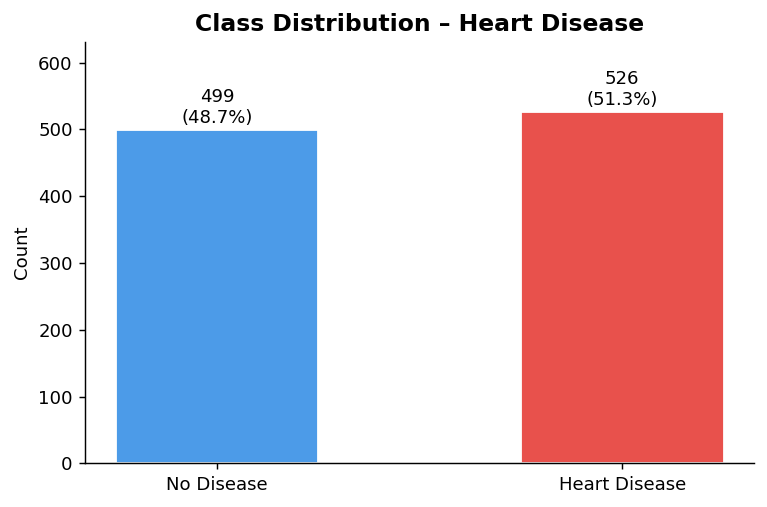

In [30]:
# ── 5a. Class Distribution ────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
counts = df[target_col].map(PALETTE_LABELS).value_counts().reindex(["No Disease", "Heart Disease"])
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE[l] for l in counts.index], edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val}\n({val/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_title("Class Distribution – Heart Disease", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
ax.set_xlabel("")
ax.set_ylim(0, counts.max() * 1.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

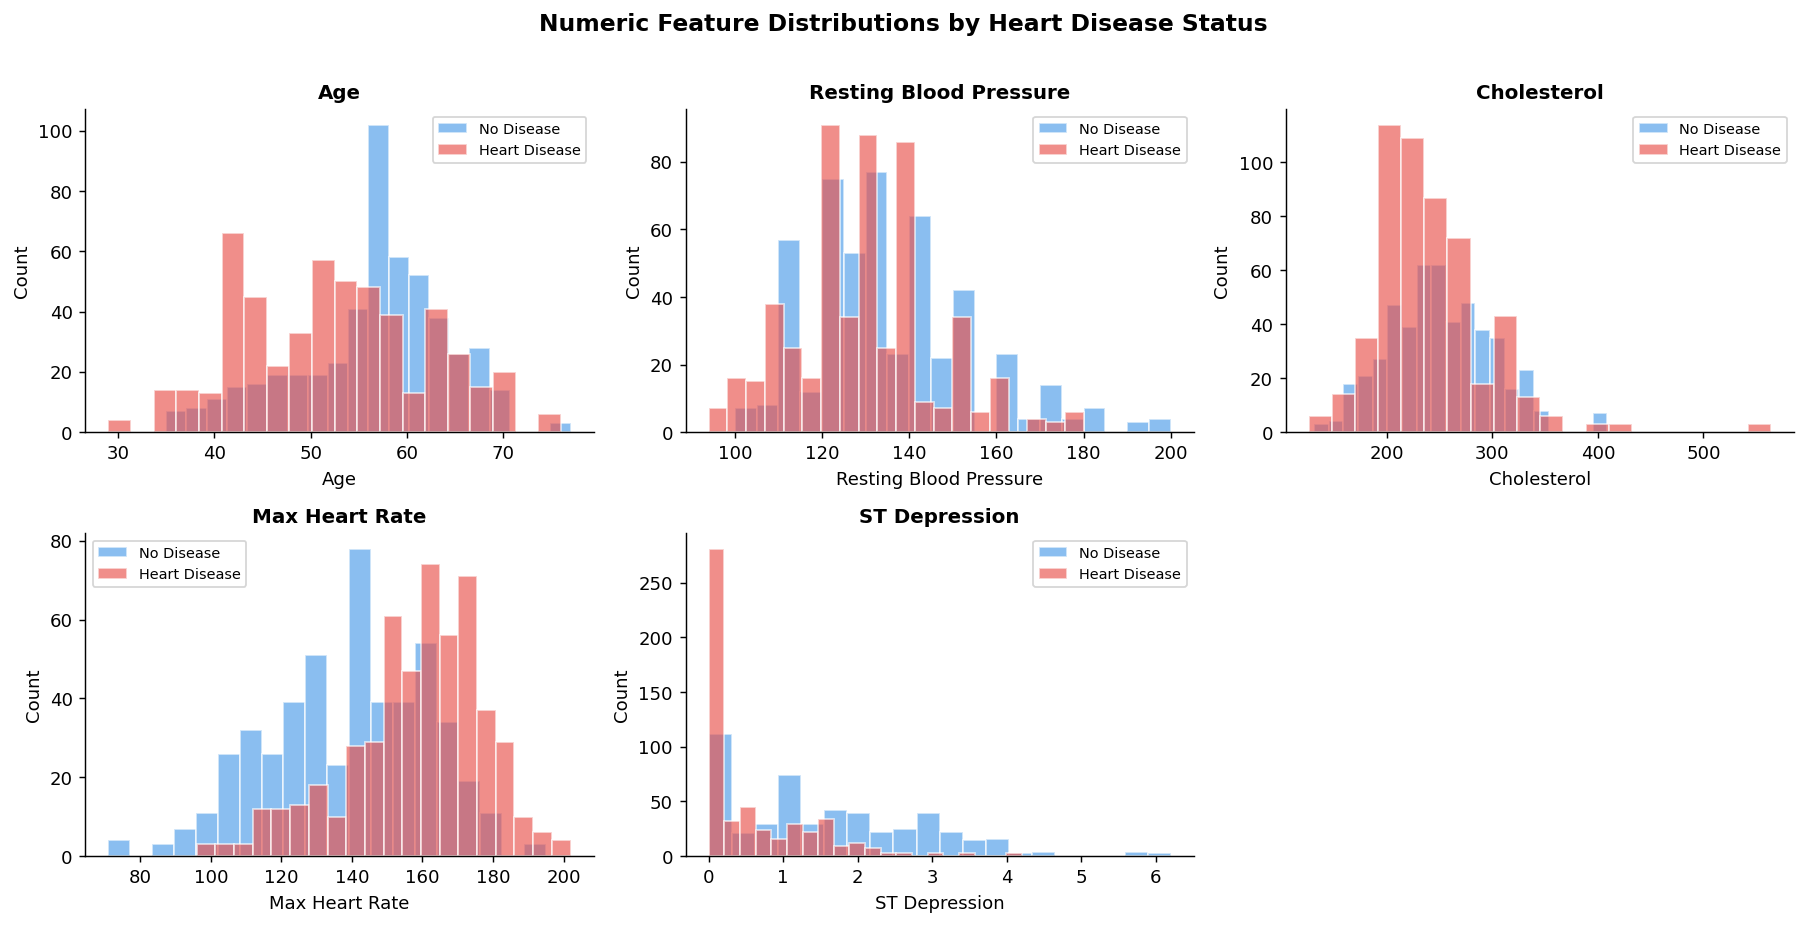

In [31]:
# ── 5b. Numeric Feature Distributions ─────────
if NUMERIC:
    n = len(NUMERIC)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    axes = axes.flatten()
    for i, feat in enumerate(NUMERIC):
        for val, (label, color) in enumerate(PALETTE.items()):
            subset = df[df[target_col] == val][feat]
            axes[i].hist(subset, bins=20, alpha=0.65, label=label,
                         color=color, edgecolor="white")
        axes[i].set_title(feat, fontsize=11, fontweight="bold")
        axes[i].set_xlabel(feat)
        axes[i].set_ylabel("Count")
        axes[i].legend(fontsize=8)
        axes[i].spines[["top", "right"]].set_visible(False)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle("Numeric Feature Distributions by Heart Disease Status",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

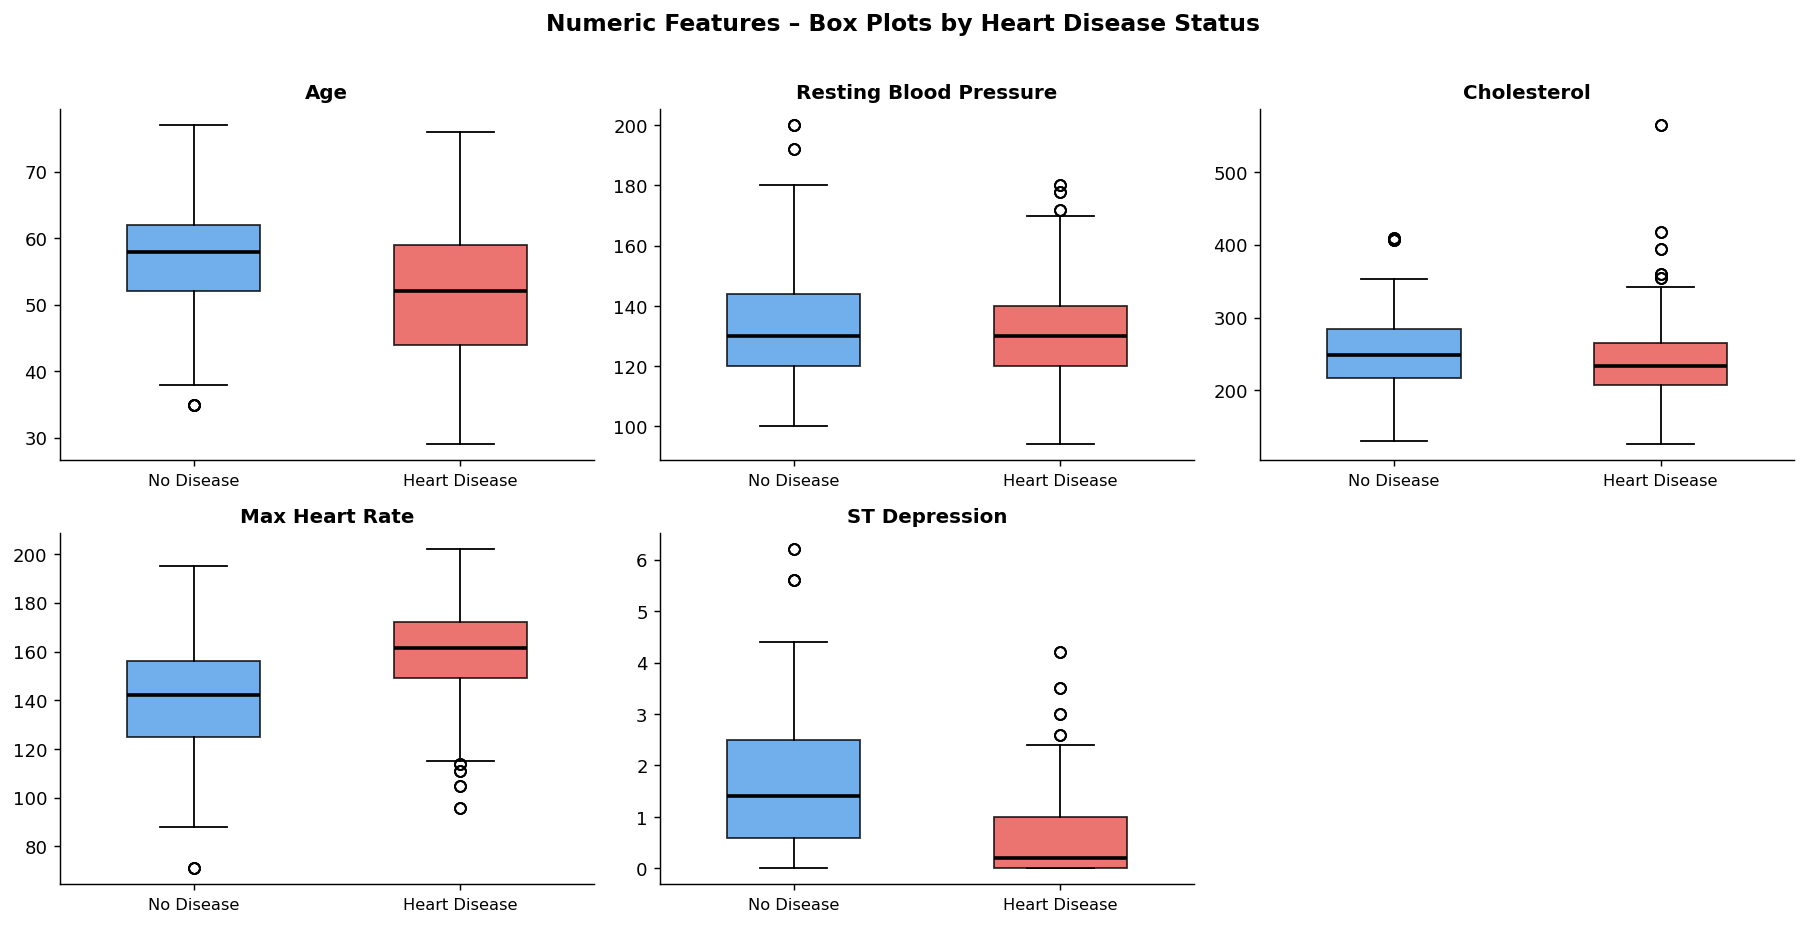

In [32]:
# ── 5c. Box Plots ─────────────────────────────
if NUMERIC:
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    axes = axes.flatten()
    for i, feat in enumerate(NUMERIC):
        groups = [df[df[target_col] == val][feat].dropna() for val in [0, 1]]  # 0=No Disease, 1=Heart Disease
        bp = axes[i].boxplot(groups, patch_artist=True, widths=0.5,
                             medianprops=dict(color="black", linewidth=2))
        for patch, color in zip(bp["boxes"], PALETTE.values()):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
        axes[i].set_xticklabels(["No Disease", "Heart Disease"], fontsize=9)  # 0=No Disease, 1=Heart Disease
        axes[i].set_title(feat, fontsize=11, fontweight="bold")
        axes[i].spines[["top", "right"]].set_visible(False)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle("Numeric Features – Box Plots by Heart Disease Status",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

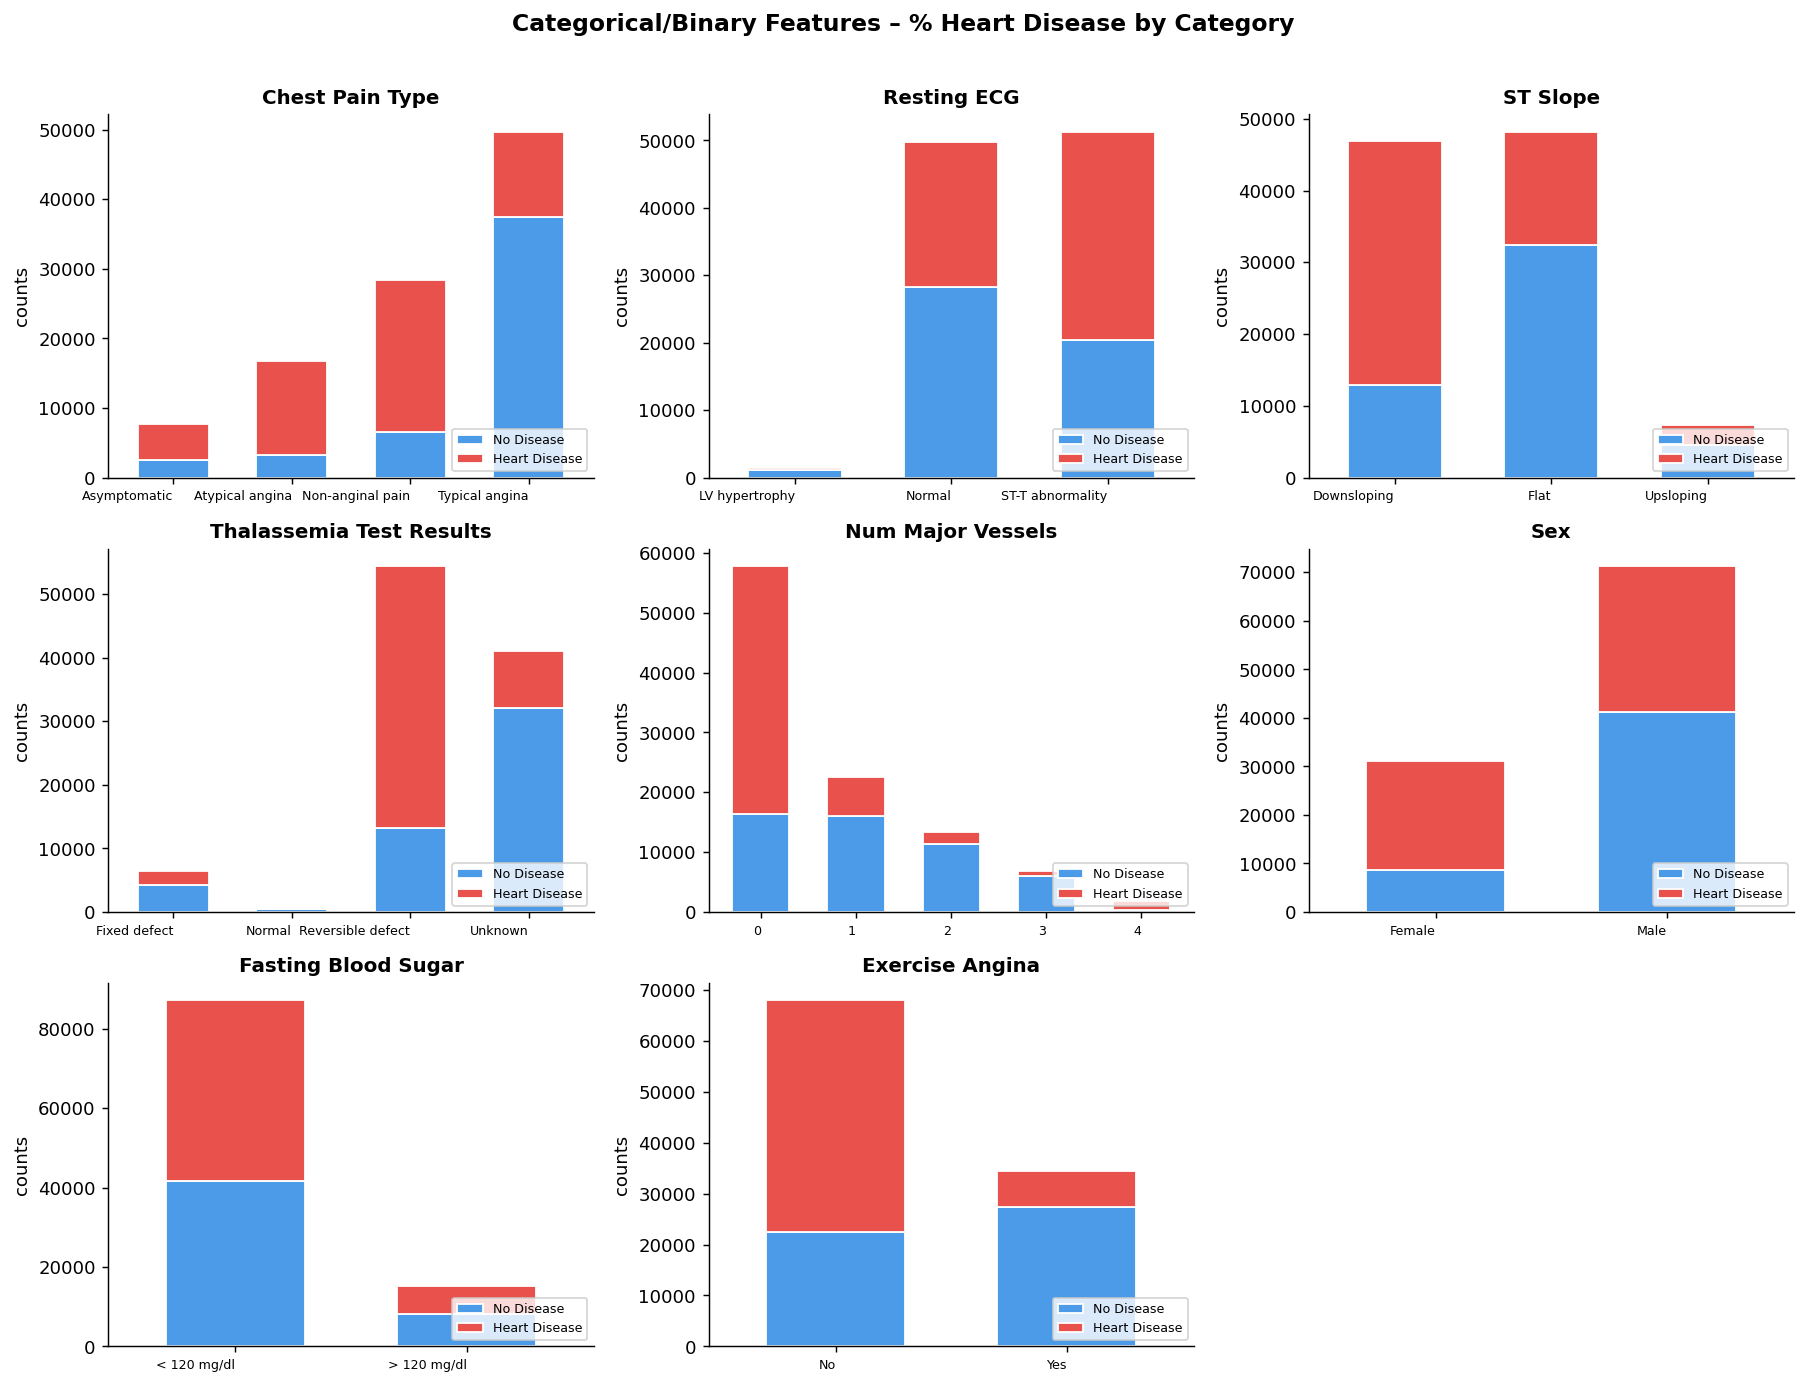

In [33]:
# ── 5d. Categorical Features (Stacked Bar) ────
cat_all = CATEGORICAL + BINARY
if cat_all:
    n = len(cat_all)
    cols2 = 3
    rows2 = (n + cols2 - 1) // cols2
    fig, axes = plt.subplots(rows2, cols2, figsize=(14, rows2 * 3.5))
    axes = axes.flatten()
    for i, feat in enumerate(cat_all):
        # Apply readable labels if mapping exists
        col_data = df[feat].map(VALUE_MAPS[feat]) if feat in VALUE_MAPS else df[feat]
        ct = pd.crosstab(col_data, df[target_col].map(PALETTE_LABELS)) * 100
        ct[["No Disease", "Heart Disease"]].plot(
            kind="bar", stacked=True, ax=axes[i],
            color=list(PALETTE.values()), edgecolor="white", width=0.6)
        axes[i].set_title(feat, fontsize=11, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("counts")
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0, ha="right", fontsize=7)
        axes[i].legend(fontsize=7, loc="lower right")
        axes[i].spines[["top", "right"]].set_visible(False)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle("Categorical/Binary Features – % Heart Disease by Category",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

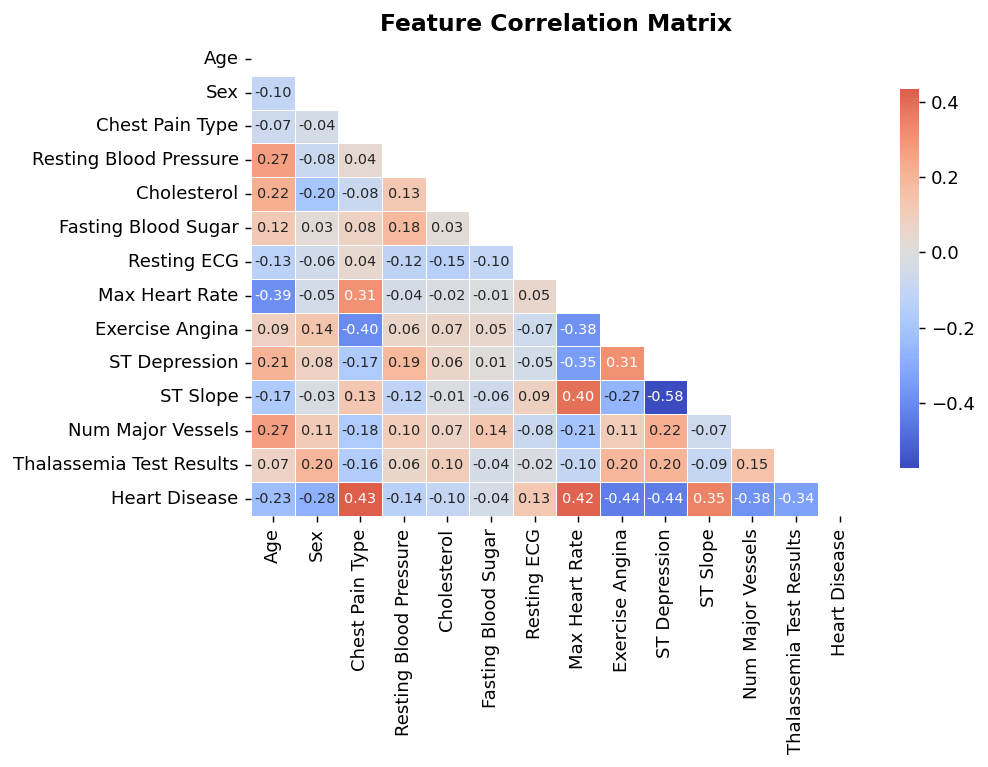

In [34]:
# ── 5e. Correlation Heatmap ───────────────────
fig, ax = plt.subplots(figsize=(8, 6))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

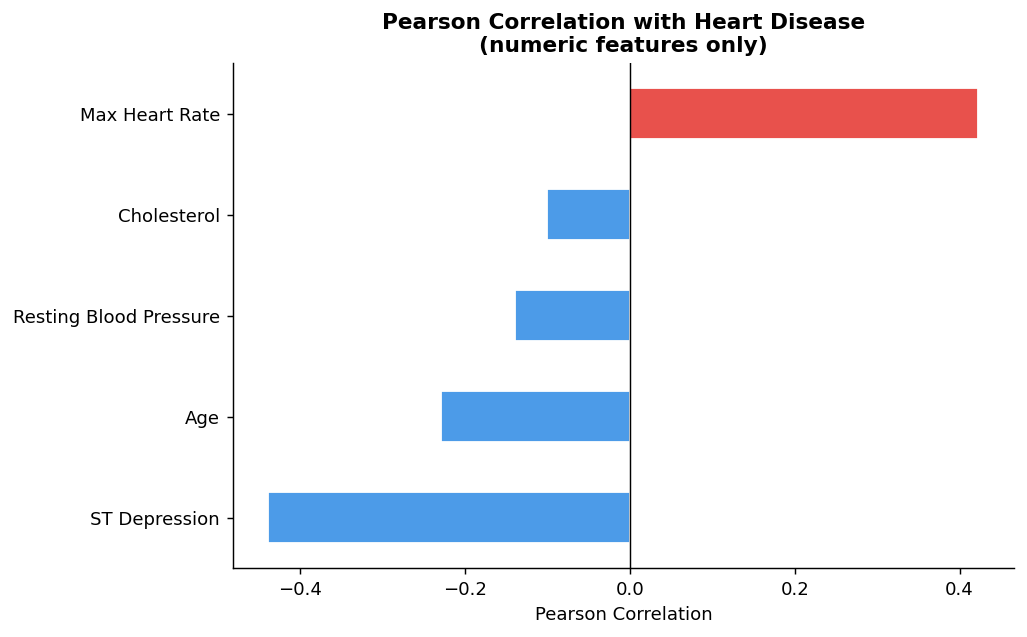

In [35]:
# ── 5f. Pearson Correlation Bar (numeric features only) ──
# Binary and categorical features are excluded — their association
# with the target is evaluated separately using Cramér's V (plot 5h).
valid_corr_cols = NUMERIC + [target_col]
valid_corr_cols = [c for c in valid_corr_cols if c in df.columns]

target_corr = (df[valid_corr_cols].corr()[target_col]
                 .drop(target_col)
                 .sort_values())
colors = ["#E8514C" if v > 0 else "#4C9BE8" for v in target_corr]
fig, ax = plt.subplots(figsize=(8, 5))
target_corr.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation with Heart Disease\n(numeric features only)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Pearson Correlation")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


[5h] Chi-square & Cramér's V for categorical & binary features:
                 Feature        Type   Chi2  p-value  Cramér's V
         Chest Pain Type categorical 280.98   0.0000       0.524
Thalassemia Test Results categorical 280.33   0.0000       0.523
       Num Major Vessels categorical 257.29   0.0000       0.501
         Exercise Angina      binary 194.82   0.0000       0.436
                ST Slope categorical 155.87   0.0000       0.390
                     Sex      binary  78.86   0.0000       0.277
             Resting ECG categorical  35.78   0.0000       0.187
     Fasting Blood Sugar      binary   1.51   0.2186       0.038


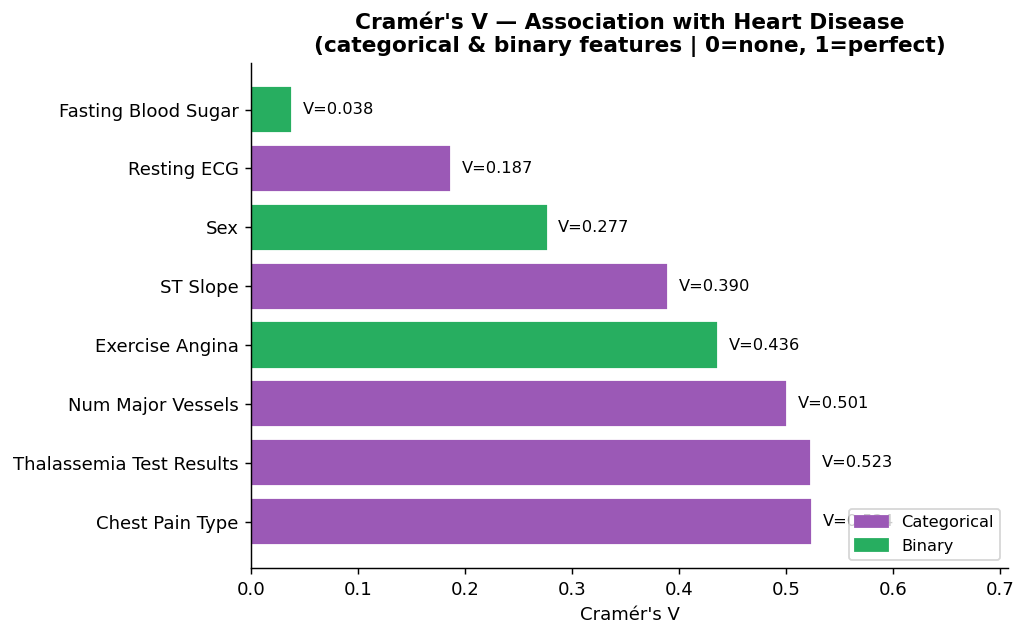

In [36]:
# ── 5h. Chi-square & Cramér's V (categorical + binary features) ─
# Binary features (Sex, FastingBS, ExerciseAngina) are included here
# alongside categorical features — Cramér's V works for any nominal
# or binary variable and is more appropriate than Pearson for these.
from scipy.stats import chi2_contingency

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    k = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * k))

cat_binary_cols = [c for c in CATEGORICAL + BINARY if c in df.columns]
if cat_binary_cols:
    results = []
    for col in cat_binary_cols:
        ct = pd.crosstab(df[col], df[target_col])
        chi2, p, _, _ = chi2_contingency(ct)
        v = cramers_v(ct)
        feature_type = "binary" if col in BINARY else "categorical"
        results.append({"Feature": col, "Type": feature_type, "Chi2": round(chi2, 2), "p-value": round(p, 4), "Cramér's V": round(v, 3)})

    results_df = pd.DataFrame(results).sort_values("Cramér's V", ascending=False)
    print("\n[5h] Chi-square & Cramér's V for categorical & binary features:")
    print(results_df.to_string(index=False))

    # Plot Cramér's V — colour by feature type
    type_colors = results_df["Type"].map({"categorical": "#9B59B6", "binary": "#27AE60"})
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(results_df["Feature"], results_df["Cramér's V"],
                   color=type_colors, edgecolor="white")
    for bar, v in zip(bars, results_df["Cramér's V"]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"V={v:.3f}", va="center", fontsize=9)
    # Legend
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color="#9B59B6", label="Categorical"),
                       Patch(color="#27AE60", label="Binary")],
              fontsize=9, loc="lower right")
    ax.set_xlim(0, results_df["Cramér's V"].max() * 1.35)
    ax.set_title("Cramér's V — Association with Heart Disease\n(categorical & binary features | 0=none, 1=perfect)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Cramér's V")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


In [37]:
# ─────────────────────────────────────────────
# 6. TRAIN / TEST SPLIT → ENCODE → SCALE (no data leakage)
# ─────────────────────────────────────────────
feature_cols_raw = [c for c in df.columns if c != target_col]
X_raw = df[feature_cols_raw].copy()
y     = df[target_col].copy()

# Split first on raw features
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

# One-hot encode
if CATEGORICAL:
    X_train = pd.get_dummies(X_train_raw, columns=CATEGORICAL, drop_first=False)
    X_test  = pd.get_dummies(X_test_raw,  columns=CATEGORICAL, drop_first=False)
    # Align columns in case test is missing a category
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
    print(f"One-hot encoded: {CATEGORICAL}")
else:
    X_train = X_train_raw.copy()
    X_test  = X_test_raw.copy()

# Binary features: label encode if needed (fit on train only)
for col in BINARY:
    if X_train[col].dtype == object:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col])
        X_test[col]  = le.transform(X_test[col])
        print(f"  Label-encoded: {col}")

print(f"  Shape after encoding — train: {X_train.shape} | test: {X_test.shape}")


One-hot encoded: ['Chest Pain Type', 'Resting ECG', 'ST Slope', 'Thalassemia Test Results', 'Num Major Vessels']
  Shape after encoding — train: (820, 27) | test: (205, 27)


In [38]:
# ─────────────────────────────────────────────
# 7. SPLIT SUMMARY
# ─────────────────────────────────────────────
print(f"\n Train/test split (80/20, stratified, seed={RANDOM_SEED}):")
print(f"  X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"  y_train distribution:\n{y_train.value_counts().to_string()}")
print(f"  y_test  distribution:\n{y_test.value_counts().to_string()}")


 Train/test split (80/20, stratified, seed=42):
  X_train: (820, 27)  |  X_test: (205, 27)
  y_train distribution:
Heart Disease
1    421
0    399
  y_test  distribution:
Heart Disease
1    105
0    100


In [39]:
# ─────────────────────────────────────────────
# 8. SCALING (fit on train only — no data leakage)
# ─────────────────────────────────────────────
print("\nScaling numeric features with StandardScaler...")
scaler = StandardScaler()
num_scale_cols = [c for c in NUMERIC if c in X_train.columns]

X_train[num_scale_cols] = scaler.fit_transform(X_train[num_scale_cols])  # fit + transform train
X_test[num_scale_cols]  = scaler.transform(X_test[num_scale_cols])       # transform test only
print(f"  Fit on train, applied to test: {num_scale_cols}")


Scaling numeric features with StandardScaler...
  Fit on train, applied to test: ['Age', 'Resting Blood Pressure', 'Cholesterol', 'Max Heart Rate', 'ST Depression']


In [40]:
# ─────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PREPROCESSING & EDA COMPLETE")
print("=" * 60)
print(f"  Total samples  : {len(df)}")
print(f"  Features (raw) : {len(all_cols) - 1}")
print(f"  Features (enc) : {X_train.shape[1]}")
print(f"  Training set   : {len(X_train)} samples")
print(f"  Test set       : {len(X_test)} samples")
print(f"  Random seed    : {RANDOM_SEED}")
print(f"  Scaler         : StandardScaler (fit on train only)")
print("=" * 60)


  PREPROCESSING & EDA COMPLETE
  Total samples  : 1025
  Features (raw) : 13
  Features (enc) : 27
  Training set   : 820 samples
  Test set       : 205 samples
  Random seed    : 42
  Scaler         : StandardScaler (fit on train only)


**Strongest predictors identified from EDA**


*Numeric Features (Pearson Correlation)*:
*   Among the numeric features, Max Heart Rate achieved during
stress testing is the strongest positively correlated feature. Patients with heart disease tend to reach higher heart rates during exertion, reflecting abnormal cardiac responses under physical stress rather than healthy cardiovascular fitness.
*   ST depression during exercise relative to rest is the strongest negatively correlated numeric feature. Greater ST depression is a direct electrocardiographic indicator of reduced blood flow to the heart muscle during exertion, making it one of the most clinically meaningful signals in the dataset.
*   Resting measurements such as cholesterol, resting blood pressure, and age show weaker correlations, suggesting that static baseline indicators are less discriminating than stress-test derived features in this dataset.

*Categorical & Binary Features (Cramér's V + Chi-square)*:
*   Chest Pain Type shows the strongest association with heart disease overall. Notably, asymptomatic patients — those who report no chest pain — have the highest proportion of heart disease cases. This counterintuitive finding reflects the clinical reality of silent ischemia, where underlying coronary disease is present without obvious symptoms, making it particularly dangerous.
*   Thalassemia Test Results is the second strongest predictor. Among its four categories, only the Reversible Defect group shows a higher proportion of heart disease cases. This is clinically consistent: a reversible defect indicates areas of the heart that receive insufficient blood flow under stress but recover at rest, which is a hallmark sign of coronary artery disease.
*   Num Major Vessels shows a result that appears counterintuitive at first glance: only patients with 0 major vessels colored by fluoroscopy have a higher proportion of heart disease. This is actually clinically valid: 0 visible vessels indicates poor blood circulation rather than the absence of blockages, since vessel visibility under fluoroscopy is a proxy for blood flow.

**Overall Takeaway**
The EDA reveals two distinct groups of important features. Stress-test indicators (MaxHR, ST Depression, Exercise Angina, ST Slope) capture how the heart behaves under physical load. Structural and clinical indicators (Chest Pain Type, Thalassemia Test Results, Num Major Vessels) reflect the underlying disease state directly. Together these two groups are expected to dominate feature importance scores in the modeling phase, strongly supporting the project hypothesis that certain medical measurements contribute more than others to predicting heart disease.


In [41]:
# ─────────────────────────────────────────────
# EXPORT PREPROCESSED DATA
# ─────────────────────────────────────────────
import os

EXPORT_DIR = os.path.join(OUTPUT_DIR, "preprocessed")
os.makedirs(EXPORT_DIR, exist_ok=True)

train_df = X_train.copy()
train_df[target_col] = y_train.values

test_df = X_test.copy()
test_df[target_col] = y_test.values

train_df.to_csv(os.path.join(EXPORT_DIR, "train.csv"), index=False)
test_df.to_csv(os.path.join(EXPORT_DIR, "test.csv"),  index=False)

print(f"Exported to {EXPORT_DIR}/")
print(f"  train.csv : {train_df.shape[0]} rows × {train_df.shape[1]} cols")
print(f"  test.csv  : {test_df.shape[0]} rows × {test_df.shape[1]} cols")

Exported to outputs/preprocessed/
  train.csv : 820 rows × 28 cols
  test.csv  : 205 rows × 28 cols
